### Mashiur Rahman 

### Assignment 10: Customer Review Sentiment Analysis

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

#**Product: Amazon Alexa**


## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)
---




### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a classification model.**



**Dataset Information:**

The dataset consists of customer reviews for Amazon Alexa products, including various features related to the product variation, customer rating, and feedback sentiment.

_Features/Columns_:
* rating: The customer rating of the product (scale of 1 to 5).
* date: The date when the review was posted.
* variation: The variation or type of Alexa product the review is for (e.g., "Charcoal Fabric", "Walnut Finish").
* verified_reviews: The actual review text written by the customer.
* feedback: The target variable indicating the sentiment of the review (1 for positive sentiment and 0 for negative sentiment).



---




In [ ]:
# Amazon Alexa Customer Review Sentiment Analysis
# Objective: Classify reviews as positive or negative using Random Forest


# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, and various sklearn modules

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# TODO: Load the dataset
# Hint: Use pandas to read the CSV file from your Google Drive

# Data Visualization and Clean Up
# TODO: Visualize the distribution of feedback
# Hint: Use seaborn's countplot function

# TODO: Visualize the relationship between variations and ratings
# Hint: Use seaborn's barplot function

# TODO: Drop irrelevant columns
# Hint: Use the drop() method to remove 'date' and 'rating' columns

# One-Hot Encoding
# TODO: Perform one-hot encoding on the 'variation' column
# Hint: Use pandas get_dummies() function

# Tokenization (Count Vectorizer)
# TODO: Tokenize the 'verified_reviews' column
# Hint: Use CountVectorizer from sklearn.feature_extraction.text

# TODO: Combine tokenized reviews with the main dataframe
# Hint: Use pd.concat() to join the dataframes

# Prepare data for modeling
# TODO: Split the data into features (X) and target (y)
# Hint: The target variable is 'feedback'

# TODO: Split the data into training and testing sets
# Hint: Use train_test_split from sklearn.model_selection

# Train the Random Forest model
# TODO: Create and train the Random Forest model
# Hint: Use RandomForestClassifier from sklearn.ensemble

# Evaluate the model
# TODO: Generate predictions and create confusion matrix
# Hint: Use the predict() method and confusion_matrix from sklearn.metrics

# TODO: Plot confusion matrix
# Hint: Use seaborn's heatmap function

# TODO: Print classification report
# Hint: Use classification_report from sklearn.metrics

# Feature Importance
# TODO: Visualize feature importance
# Hint: Access feature_importances_ attribute of the trained model

# TODO: Make predictions on new data
# Hint: Create a function that takes a new review text, preprocesses it,
# and uses the trained model to predict its sentiment

# Example usage of your prediction function:
# new_review = "I love my Alexa device! It's so helpful."
# predicted_sentiment = predict_sentiment(new_review)
# print(f"The sentiment of the new review is: {predicted_sentiment}")

In [ ]:
# Task 1: Import Libraries and Dataset

# Hint: You need to import libraries like pandas, numpy, matplotlib, seaborn, etc.
# Don't forget to mount Google Drive and load the CSV file using pandas.
# Use `pd.read_csv()` to load the data into a pandas DataFrame.

# TODO: Import necessary libraries

# TODO: Mount Google Drive

# TODO: Load the dataset into a DataFrame and preview the first few rows.


# Hint: Use `sns.countplot()` to visualize the feedback distribution and a bar plot to compare variations and feedback.
# Drop the columns 'date' and 'rating' as they are not relevant for the analysis.

# TODO: Visualize the distribution of feedback (positive/negative)

# TODO: Visualize the relationship between product variation and feedback

# TODO: Drop irrelevant columns ('date', 'rating')



# Hint: Use `pd.get_dummies()` to create one-hot encoded columns for 'variation'.
# Then, concatenate these encoded columns back to the original DataFrame and drop the 'variation' column.

# TODO: Perform one-hot encoding on the 'variation' column




# Hint: Use `CountVectorizer` to tokenize the text data and convert it into numerical representation.
# After transforming the text, drop the 'verified_reviews' column and concatenate the numerical data with the rest of the DataFrame.

# TODO: Tokenize the 'verified_reviews' column using CountVectorizer






# Hint: Use `train_test_split()` to split the data into training and testing sets.
# You need to specify `test_size=0.2` to reserve 20% of the data for testing.

# TODO: Split the data into training and testing sets




# Hint: Initialize a `RandomForestClassifier` with 100 estimators.
# Use the `fit()` method to train the model on the training data.

# TODO: Define and train a Random Forest Classifier





# Hint: Use the `predict()` method to generate predictions for the test data.
# Use `confusion_matrix()` to create the confusion matrix and visualize it using a heatmap.
# Print out a `classification_report()` to evaluate the model's precision, recall, and F1 score.

# TODO: Generate predictions and evaluate the model's performance using a confusion matrix and classification report



# Task 8: Analyze Model Performance
# Hint: Use the `score()` method to calculate accuracy for both training and test sets.
# Compare the results and discuss if the model is overfitting or underfitting.

# TODO: Compare training and testing accuracy and discuss model performance


#### 2. Load Dataset

In [2]:
file_path = "amazon_alexa.tsv"

df = pd.read_csv(file_path, sep="\t")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (3150, 5)


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


#### 3. Explore the Dataset

In [3]:
# Display the dataset dimensions
print("Dataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset information:")
df.info()

Dataset shape: (3150, 5)

Column names:
['rating', 'date', 'variation', 'verified_reviews', 'feedback']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   rating            3150 non-null   int64
 1   date              3150 non-null   str  
 2   variation         3150 non-null   str  
 3   verified_reviews  3149 non-null   str  
 4   feedback          3150 non-null   int64
dtypes: int64(2), str(3)
memory usage: 123.2 KB


In [4]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


In [5]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 715


#### 4. Clean the Review Data

In [6]:
# Replace missing reviews with empty strings
df["verified_reviews"] = df["verified_reviews"].fillna("")

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (2435, 5)


#### 5. Visualize Feedback Distribution

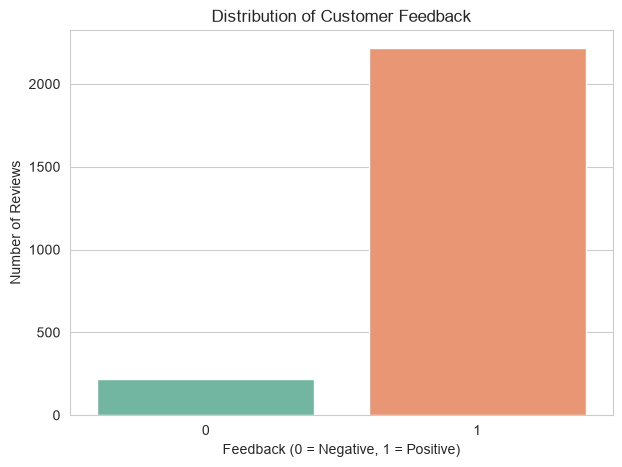

In [7]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="feedback",
    hue="feedback",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Customer Feedback")
plt.xlabel("Feedback (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Reviews")
plt.show()

#### 6. Visualize Product Variation and Feedback

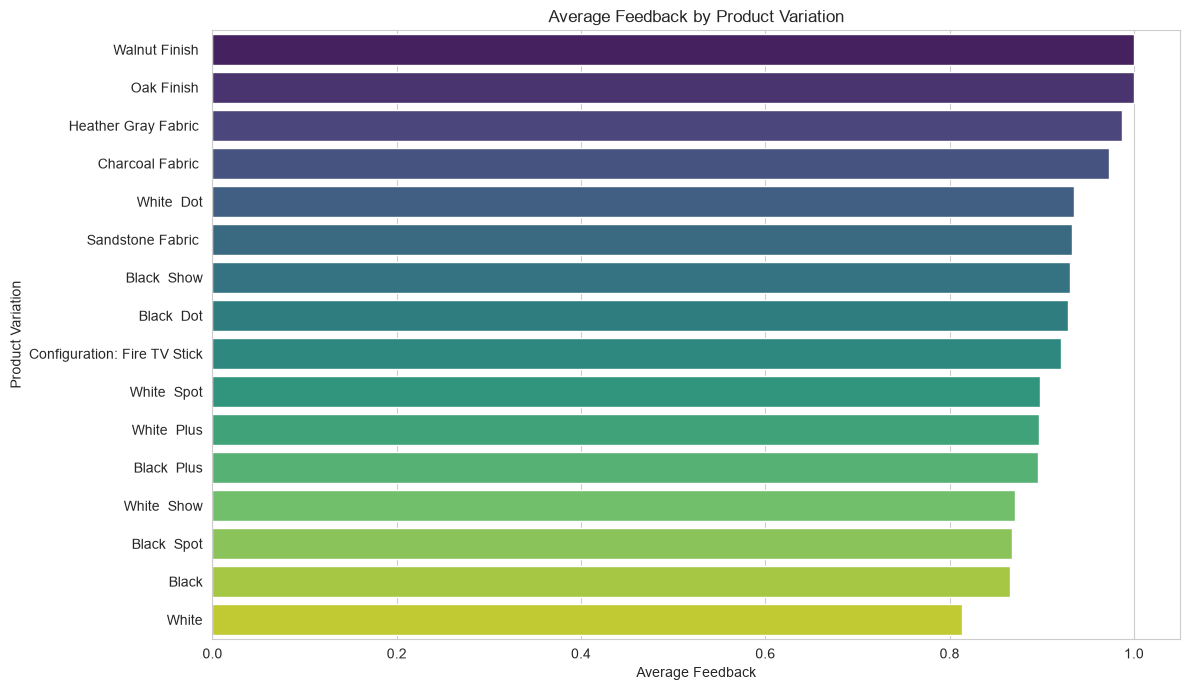

In [8]:
variation_feedback = (
    df.groupby("variation")["feedback"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=variation_feedback,
    x="feedback",
    y="variation",
    hue="variation",
    palette="viridis",
    legend=False
)

plt.title("Average Feedback by Product Variation")
plt.xlabel("Average Feedback")
plt.ylabel("Product Variation")
plt.tight_layout()
plt.show()

#### 7. Visualize Product Variation and Rating

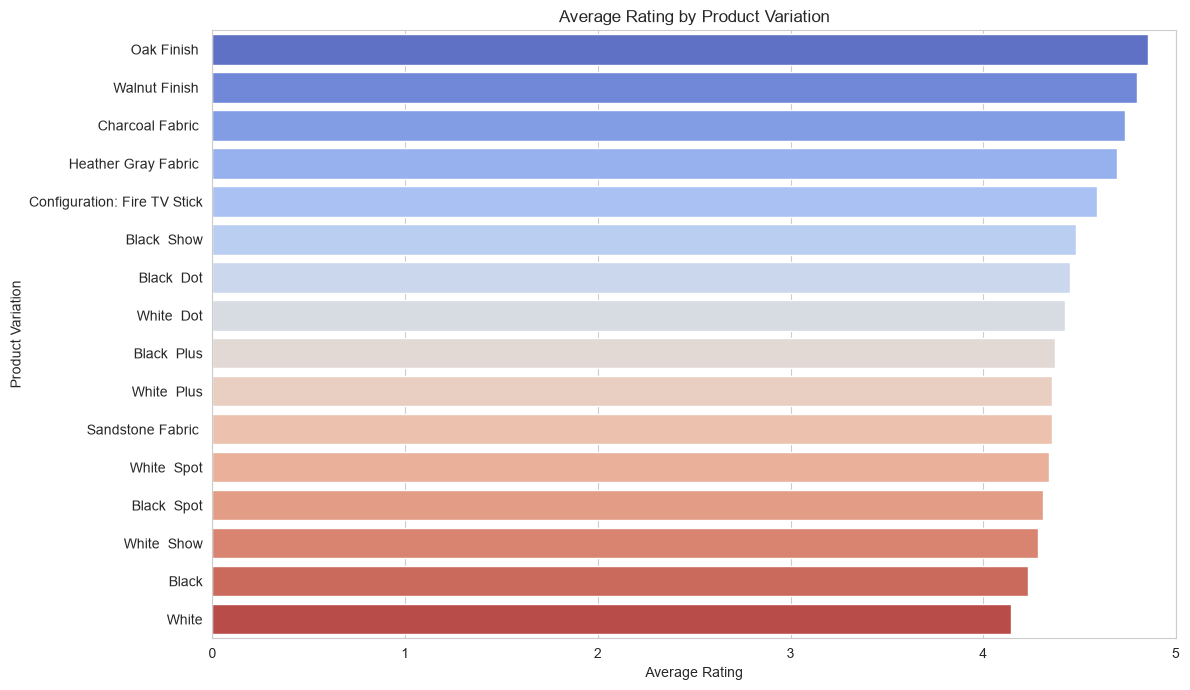

In [9]:
variation_rating = (
    df.groupby("variation")["rating"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=variation_rating,
    x="rating",
    y="variation",
    hue="variation",
    palette="coolwarm",
    legend=False
)

plt.title("Average Rating by Product Variation")
plt.xlabel("Average Rating")
plt.ylabel("Product Variation")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

#### 8. Prepare a Fresh DataFrame

In [10]:
# Create a fresh copy from the original dataset
model_df = df.copy()

# Replace missing reviews with empty text
model_df["verified_reviews"] = (
    model_df["verified_reviews"]
    .fillna("")
    .astype(str)
)

# Remove irrelevant columns
model_df.drop(
    columns=["date", "rating"],
    inplace=True
)

model_df.head()

,variation,verified_reviews,feedback
0,Charcoal Fabric,Love my Echo!,1
1,Charcoal Fabric,Loved it!,1
2,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,Charcoal Fabric,Music,1


#### 9. One-Hot Encode Product Variation

In [11]:
variation_encoded = pd.get_dummies(
    model_df["variation"],
    prefix="variation",
    dtype=int
)

variation_encoded.head()

,variation_Black,variation_Black Dot,variation_Black Plus,variation_Black Show,variation_Black Spot,variation_Charcoal Fabric,variation_Configuration: Fire TV Stick,variation_Heather Gray Fabric,variation_Oak Finish,variation_Sandstone Fabric,variation_Walnut Finish,variation_White,variation_White Dot,variation_White Plus,variation_White Show,variation_White Spot
0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


#### 10. Tokenize the Customer Reviews

In [12]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=3000
)

review_matrix = vectorizer.fit_transform(
    model_df["verified_reviews"]
)

# Add word_ prefix to prevent duplicate column names
review_columns = [
    "word_" + word
    for word in vectorizer.get_feature_names_out()
]

review_df = pd.DataFrame(
    review_matrix.toarray(),
    columns=review_columns,
    index=model_df.index
)

print("Number of text features:", review_df.shape[1])
review_df.head()

Number of text features: 3000


,word_00,word_10,word_100,word_100x,word_11,word_1100sf,word_12,word_129,word_12am,word_15,...,word_york,word_young,word_younger,word_youngest,word_youtube,word_yr,word_yrs,word_yup,word_zero,word_zigbee
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### 11: Combine the Input Features

In [13]:
# Combine variation and review features
X = pd.concat(
    [
        variation_encoded.reset_index(drop=True),
        review_df.reset_index(drop=True)
    ],
    axis=1
)

# Create the target variable
y = model_df["feedback"].reset_index(drop=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Duplicate columns:", X.columns.duplicated().sum())

X shape: (2435, 3016)
y shape: (2435,)
Duplicate columns: 0


#### 12: Verify the Prepared Data

In [14]:
feature_columns = X.columns.tolist()

print("Number of input features:", len(feature_columns))
print("\nTarget distribution:")
print(y.value_counts())

X.head()

Number of input features: 3016

Target distribution:
feedback
1    2214
0     221
Name: count, dtype: int64


,variation_Black,variation_Black Dot,variation_Black Plus,variation_Black Show,variation_Black Spot,variation_Charcoal Fabric,variation_Configuration: Fire TV Stick,variation_Heather Gray Fabric,variation_Oak Finish,variation_Sandstone Fabric,...,word_york,word_young,word_younger,word_youngest,word_youtube,word_yr,word_yrs,word_yup,word_zero,word_zigbee
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### 13. Split the Training and Testing Data

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1948, 3016)
Testing features: (487, 3016)
Training target: (1948,)
Testing target: (487,)


#### 14. Train the Random Forest Model

In [16]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model training completed.")

Random Forest model training completed.


#### 15. Generate Predictions

In [22]:
y_pred = random_forest_model.predict(X_test)

print("First 10 predicted values:")
print(y_pred[:10])

First 10 predicted values:
[1 1 1 1 1 1 1 1 1 1]


#### 16. Create the Confusion Matrix

In [23]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 15  29]
 [ 29 414]]


#### 17. Visualize the Confusion Matrix

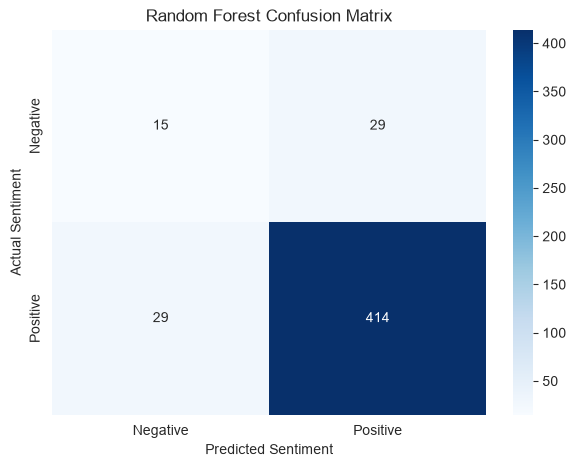

In [24]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

#### 18. Display the Classification Report

In [25]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

Classification Report:

              precision    recall  f1-score   support

    Negative       0.34      0.34      0.34        44
    Positive       0.93      0.93      0.93       443

    accuracy                           0.88       487
   macro avg       0.64      0.64      0.64       487
weighted avg       0.88      0.88      0.88       487



#### 19. Compare Training and Testing Accuracy

In [26]:
training_accuracy = random_forest_model.score(X_train, y_train)
testing_accuracy = random_forest_model.score(X_test, y_test)

print(f"Training Accuracy: {training_accuracy:.2%}")
print(f"Testing Accuracy: {testing_accuracy:.2%}")

Training Accuracy: 98.36%
Testing Accuracy: 88.09%


In [27]:
accuracy_difference = training_accuracy - testing_accuracy

if accuracy_difference > 0.10:
    print("The model may be overfitting because training accuracy is much higher.")
elif training_accuracy < 0.70 and testing_accuracy < 0.70:
    print("The model may be underfitting because both accuracy scores are low.")
else:
    print("The model has reasonably balanced performance.")

The model may be overfitting because training accuracy is much higher.


#### 20. Visualize Feature Importance

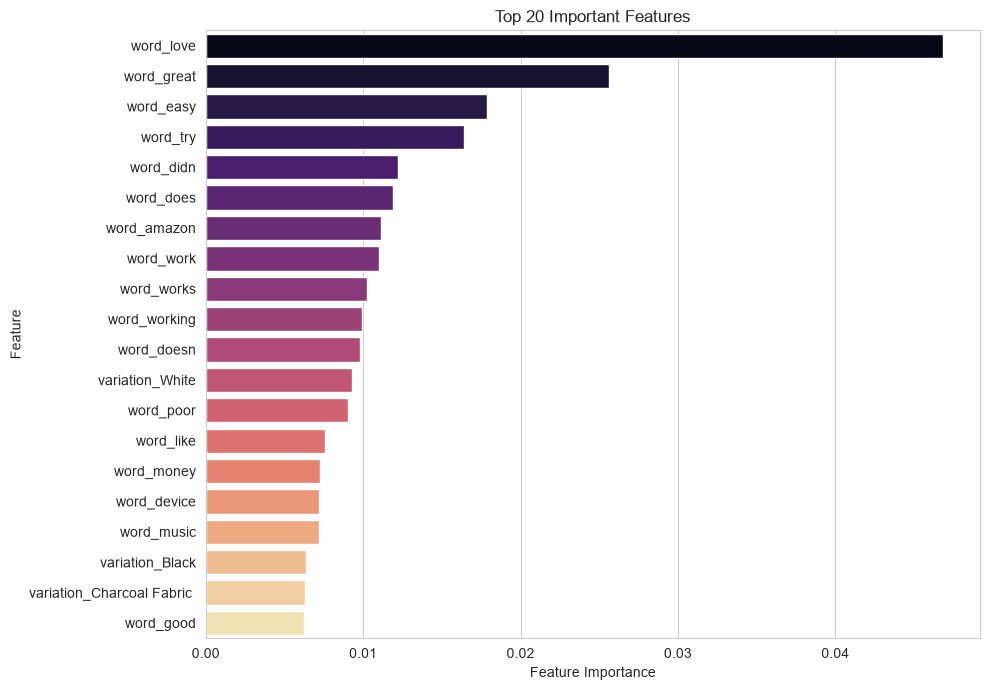

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

# Select the 20 most important features
top_features = (
    feature_importance
    .sort_values(by="Importance", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="magma",
    legend=False
)

plt.title("Top 20 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### 21. Create a Sentiment Prediction Function

In [29]:
def predict_sentiment(review_text, product_variation=None):
    # Transform the new review
    review_vector = vectorizer.transform([review_text])

    # Use the same word_ prefix used during training
    review_columns = [
        "word_" + word
        for word in vectorizer.get_feature_names_out()
    ]

    review_features = pd.DataFrame(
        review_vector.toarray(),
        columns=review_columns
    )

    # Create an empty row containing all expected features
    new_data = pd.DataFrame(
        0,
        index=[0],
        columns=feature_columns
    )

    # Add the tokenized review values
    common_columns = review_features.columns.intersection(
        new_data.columns
    )

    new_data.loc[0, common_columns] = (
        review_features.loc[0, common_columns].values
    )

    # Add the product variation if provided
    if product_variation is not None:
        variation_column = "variation_" + product_variation

        if variation_column in new_data.columns:
            new_data.loc[0, variation_column] = 1

    prediction = random_forest_model.predict(new_data)[0]
    confidence = random_forest_model.predict_proba(new_data)[0].max()

    sentiment = "Positive" if prediction == 1 else "Negative"

    return sentiment, confidence

#### 22. Test the Prediction Function

In [ ]:
new_review = "I love my Alexa device! It is very helpful and easy to use."

predicted_sentiment, confidence = predict_sentiment(new_review)

print("New review:", new_review)
print("Predicted sentiment:", predicted_sentiment)
print(f"Confidence: {confidence:.2%}")

In [30]:
new_review = "This product is terrible and it stopped working after one day."

predicted_sentiment, confidence = predict_sentiment(new_review)

print("New review:", new_review)
print("Predicted sentiment:", predicted_sentiment)
print(f"Confidence: {confidence:.2%}")

New review: This product is terrible and it stopped working after one day.
Predicted sentiment: Negative
Confidence: 89.00%


#### 23. Final Conclusion

The Amazon Alexa customer reviews were cleaned and transformed into numerical
features using one-hot encoding and CountVectorizer. A Random Forest
classification model was trained to classify customer reviews as positive or
negative. The confusion matrix, classification report, training accuracy and
testing accuracy were used to evaluate the model. The model can also predict
the sentiment of new customer reviews.